# Importação das bibliotecas básica

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Base de dados de crédito

In [2]:
df = pd.read_csv('../data/credit_data.csv')
df

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [3]:
df.head(10)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
5,6,24904.064140,57.471607,15.498598,0
6,7,48430.359613,26.809132,5722.581981,0
7,8,24500.141984,32.897548,2971.003310,1
8,9,40654.892537,55.496853,4755.825280,0
9,10,25075.872771,39.776378,1409.230371,0


In [4]:
df.tail(10)

,clientid,income,age,loan,default
1990,1991,34237.575419,34.101654,2658.090632,0
1991,1992,26300.446554,45.539385,2317.393678,0
1992,1993,30803.806165,23.250084,623.024153,0
1993,1994,54421.410155,26.821928,3273.631823,0
1994,1995,24254.700791,37.751622,2225.284643,0
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0
1999,2000,69436.579552,56.152617,7378.833599,0


In [5]:
df.describe()

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


In [6]:
df[df['income'] >= 69995.685578]

,clientid,income,age,loan,default
422,423,69995.685578,52.719673,2084.370861,0


In [7]:
df[df['loan'] <= 1.377630]

,clientid,income,age,loan,default
865,866,28072.604355,54.142548,1.37763,0


## Visualização dos Dados

In [8]:
np.unique(df['default'], return_counts=True)

(array([0, 1]), array([1717,  283]))

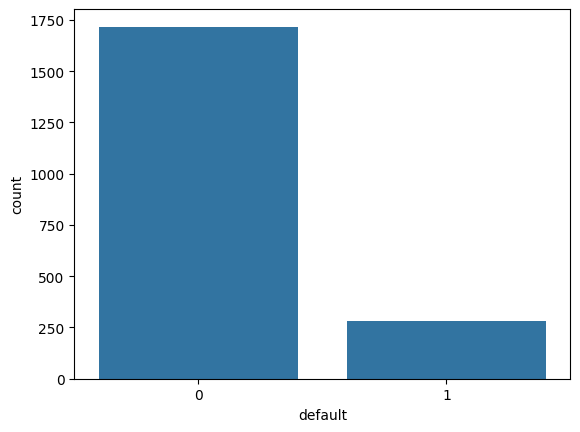

In [9]:
sns.countplot(x=df['default']);

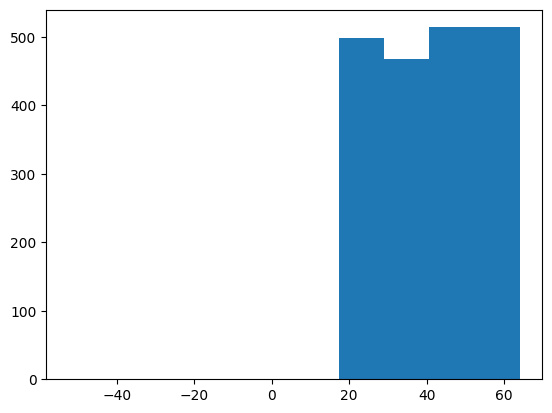

In [10]:
plt.hist(x=df['age']);

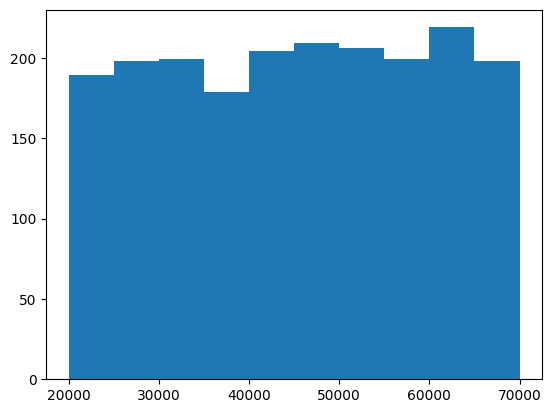

In [11]:
plt.hist(x=df['income']);

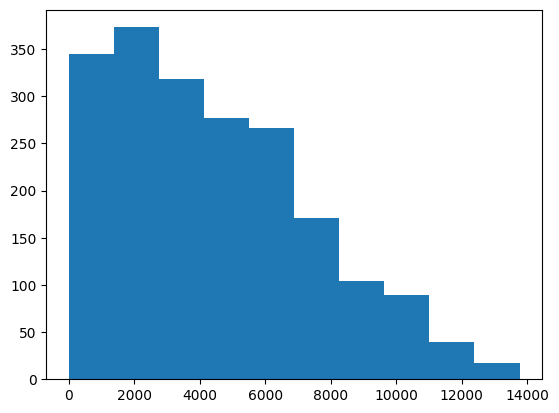

In [12]:
plt.hist(x=df['loan']);

In [13]:
grafico = px.scatter_matrix(df, dimensions=['age', 'income', 'loan'], color= 'default')
grafico.show()

## Tratamento de valores inconsistente

In [14]:
df.loc[df['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [15]:
df[df['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [16]:
# Apagando a coluna inteira
df2 = df.copy()
df2 = df2.drop('age', axis=1)
df2

,clientid,income,loan,default
0,1,66155.925095,8106.532131,0
1,2,34415.153966,6564.745018,0
2,3,57317.170063,8020.953296,0
3,4,42709.534201,6103.642260,0
4,5,66952.688845,8770.099235,1
...,...,...,...,...
1995,1996,59221.044874,1926.729397,0
1996,1997,69516.127573,3503.176156,0
1997,1998,44311.449262,5522.786693,1
1998,1999,43756.056605,1622.722598,0


In [17]:
# Apagando as linhas
df3 = df.copy()
df3 = df3.drop(df[df['age'] < 0].index)
df3

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [18]:
df3[df3['age'] < 0]

,clientid,income,age,loan,default


In [19]:
# Preencher os valores inconsistente manualmente
df['age'][df['age'] > 0].mean()

np.float64(40.92770044906149)

In [20]:
df['age'] = df['age'].apply(lambda x: abs(x)) # transformando valores negativo para positivo
df[df['age'] < 0]

,clientid,income,age,loan,default


In [21]:
df.iloc[[15, 21, 26]]

,clientid,income,age,loan,default
15,16,50501.726689,28.218361,3977.287432,0
21,22,32197.620701,52.423280,4244.057136,0
26,27,63287.038908,36.496976,9595.286289,0


In [22]:
df['age'].mean()

np.float64(40.9248739670422)

## Tratamento de valores faltantes

In [23]:
df.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

In [24]:
df.loc[pd.isnull(df['age'])]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [25]:
df.fillna({'age': df['age'].mean()}, inplace=True)
df.loc[pd.isnull(df['age'])]

,clientid,income,age,loan,default


In [26]:
df.loc[
    (df['clientid'] == 29) |
    (df['clientid'] == 31) |
    (df['clientid'] == 32)
]

,clientid,income,age,loan,default
28,29,59417.805406,40.924874,2082.625938,0
30,31,48528.852796,40.924874,6155.784670,0
31,32,23526.302555,40.924874,2862.010139,0


In [27]:
df.loc[df['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.924874,2082.625938,0
30,31,48528.852796,40.924874,6155.784670,0
31,32,23526.302555,40.924874,2862.010139,0


## Divisão entre previsores e classe

In [28]:
X_credit = df.iloc[:, 1:4].values
X_credit

array([[6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [6.94365796e+04, 5.61526170e+01, 7.37883360e+03]], shape=(2000, 3))

In [29]:
y_credit = df.iloc[:, 4].values
y_credit

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [30]:
type(X_credit), type(y_credit)

(numpy.ndarray, numpy.ndarray)

## Escalonamento dos valores

In [31]:
X_credit

array([[6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [6.94365796e+04, 5.61526170e+01, 7.37883360e+03]], shape=(2000, 3))

In [32]:
X_credit[:, 0].min(), X_credit[:, 1].min(), X_credit[:, 2].min()

(np.float64(20014.4894700497),
 np.float64(18.055188510566897),
 np.float64(1.37762959325451))

In [33]:
X_credit[:, 0].max(), X_credit[:, 1].max(), X_credit[:, 2].max()

(np.float64(69995.6855783239),
 np.float64(63.971795841120205),
 np.float64(13766.0512393337))

In [34]:
from sklearn.preprocessing import StandardScaler
scaler_credit = StandardScaler()
X_credit = scaler_credit.fit_transform(X_credit)

In [35]:
X_credit[:, 0].min(), X_credit[:, 1].min(), X_credit[:, 2].min()

(np.float64(-1.7676158019964077),
 np.float64(-1.7254323179314786),
 np.float64(-1.4592791099462408))

In [36]:
X_credit[:, 0].max(), X_credit[:, 1].max(), X_credit[:, 2].max()

(np.float64(1.7220222385319197),
 np.float64(1.738804143417582),
 np.float64(3.0616609141708273))

In [37]:
X_credit

array([[ 1.45393393,  1.36498445,  1.20281942],
       [-0.76217555,  0.54263059,  0.69642695],
       [ 0.83682073,  1.67363771,  1.17471147],
       ...,
       [-0.07122592, -0.97383827,  0.35420081],
       [-0.11000289,  1.73880414, -0.92675625],
       [ 1.682986  ,  1.14887632,  0.96381038]], shape=(2000, 3))

## Base de dados do censo

In [38]:
df_census = pd.read_csv('../data/census.csv')
df_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [39]:
df_census.describe()

,age,final-weight,education-num,capital-gain,capital-loos,hour-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [40]:
df_census.isnull().sum()

age               0
workclass         0
final-weight      0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loos      0
hour-per-week     0
native-country    0
income            0
dtype: int64

In [41]:
df_census.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   final-weight    32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loos    32561 non-null  int64
 12  hour-per-week   32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


## Visualização dos dados

In [42]:
np.unique(df_census['income'], return_counts=True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

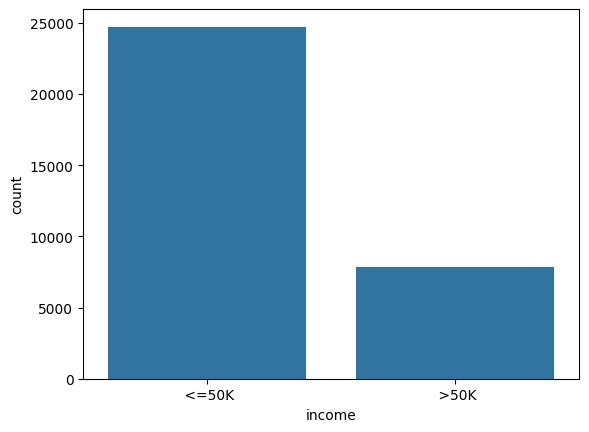

In [43]:
sns.countplot(x=df_census['income']);

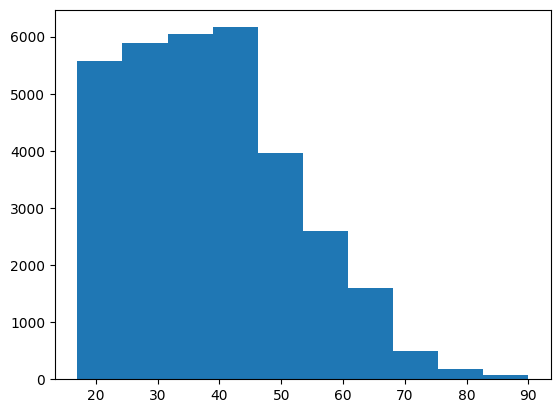

In [44]:
plt.hist(df_census['age']);

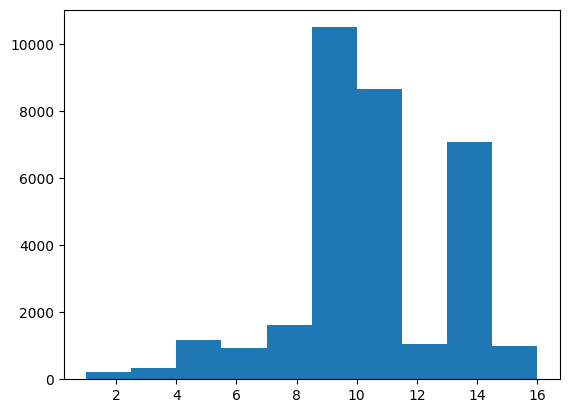

In [45]:
plt.hist(df_census['education-num']);

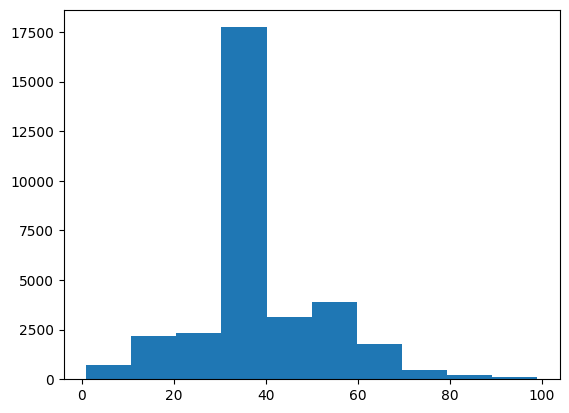

In [46]:
plt.hist(df_census['hour-per-week']);

In [47]:
grafico = px.treemap(df_census, path=['workclass', 'age'])
grafico.show()

In [48]:
grafico = px.treemap(df_census, path=['occupation', 'relationship', 'age'])
grafico.show()

In [49]:
grafico = px.parallel_categories(df_census, dimensions=['occupation', 'workclass', 'income'])
grafico.show()

In [50]:
grafico = px.parallel_categories(df_census, dimensions=['education', 'income'])
grafico.show()

## Divisão das bases em treinamento e teste

In [51]:
X_census = df_census.iloc[:, 0:14].values
X_census

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      shape=(32561, 14), dtype=object)

In [52]:
y_census = df_census.iloc[:, 14].values

In [53]:
y_census

<StringArray>
[' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
  ' >50K',  ' >50K',  ' >50K',
 ...
 ' <=50K', ' <=50K', ' <=50K',  ' >50K', ' <=50K', ' <=50K',  ' >50K',
 ' <=50K', ' <=50K',  ' >50K']
Length: 32561, dtype: str

## Tratamento de atributos categóricos

### LabelEncoder

In [54]:
from sklearn.preprocessing import LabelEncoder

In [55]:
label_encoder_teste = LabelEncoder()

In [56]:
X_census[:, 1]

array([' State-gov', ' Self-emp-not-inc', ' Private', ..., ' Private',
       ' Private', ' Self-emp-inc'], shape=(32561,), dtype=object)

In [57]:
teste = label_encoder_teste.fit_transform(X_census[:,1])

In [58]:
teste

array([7, 6, 4, ..., 4, 4, 5], shape=(32561,))

In [59]:
X_census[0]

array([39, ' State-gov', 77516, ' Bachelors', 13, ' Never-married',
       ' Adm-clerical', ' Not-in-family', ' White', ' Male', 2174, 0, 40,
       ' United-States'], dtype=object)

In [60]:
type(X_census)

numpy.ndarray

In [61]:
def transformar_categoricos(X):
    X = X.copy()
    encoders = {}
    for i in range(X.shape[1]):
        coluna = X[:, i]
        if isinstance(coluna[0], str):
            le = LabelEncoder()
            X[:, i] = le.fit_transform(coluna)
            encoders = le
    return X, encoders

In [62]:
X_censuslc = transformar_categoricos(X_census)
X_censuslc

(array([[39, 7, 77516, ..., 0, 40, 39],
        [50, 6, 83311, ..., 0, 13, 39],
        [38, 4, 215646, ..., 0, 40, 39],
        ...,
        [58, 4, 151910, ..., 0, 40, 39],
        [22, 4, 201490, ..., 0, 20, 39],
        [52, 5, 287927, ..., 0, 40, 39]], shape=(32561, 14), dtype=object),
 LabelEncoder())

In [63]:
X_censuslc[0]

array([[39, 7, 77516, ..., 0, 40, 39],
       [50, 6, 83311, ..., 0, 13, 39],
       [38, 4, 215646, ..., 0, 40, 39],
       ...,
       [58, 4, 151910, ..., 0, 40, 39],
       [22, 4, 201490, ..., 0, 20, 39],
       [52, 5, 287927, ..., 0, 40, 39]], shape=(32561, 14), dtype=object)

### OneHotEncoder

In [64]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [65]:
onehotcoder_census = ColumnTransformer(
    transformers=[(
        'OneHot', OneHotEncoder(), [1, 3, 5, 6, 7, 8, 9, 13]
        )],
    remainder='passthrough'
)

In [66]:
X_censusoh = onehotcoder_census.fit_transform(X_census).toarray()
X_censusoh

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 2.1740e+03, 0.0000e+00,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.3000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       ...,
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.5024e+04, 0.0000e+00,
        4.0000e+01]], shape=(32561, 108))

In [67]:
X_censusoh[0]

array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e

In [68]:
X_censusoh.shape

(32561, 108)

### Escalonamento dos valores

## Divisão das bases em treinamento e teste